# Setup 

Outline: 

0) Annotations (done from Aaron's add_annotations.py) -> EDF file with both events + eeg data
1) Filtering (DONE)
2) ICA artifact removal (Skipped because the built in artifact removal is good enough)
3) Binning
4) PCA

In [2]:
pip install mne numpy pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 12.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Read an example edf file
import mne

edf_path = 'eeg/data_0002_raw.edf'
raw = mne.io.read_raw(edf_path, preload=True) # Change to FIF once Aaron is done
info = raw.info.to_json_dict()

Extracting EDF parameters from eeg/data_0002_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 433799  =      0.000 ...  1445.997 secs...


# Filtering

Effective window size : 6.827 (s)
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1981 samples (6.603 s)

Effective window size : 6.827 (s)
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition band

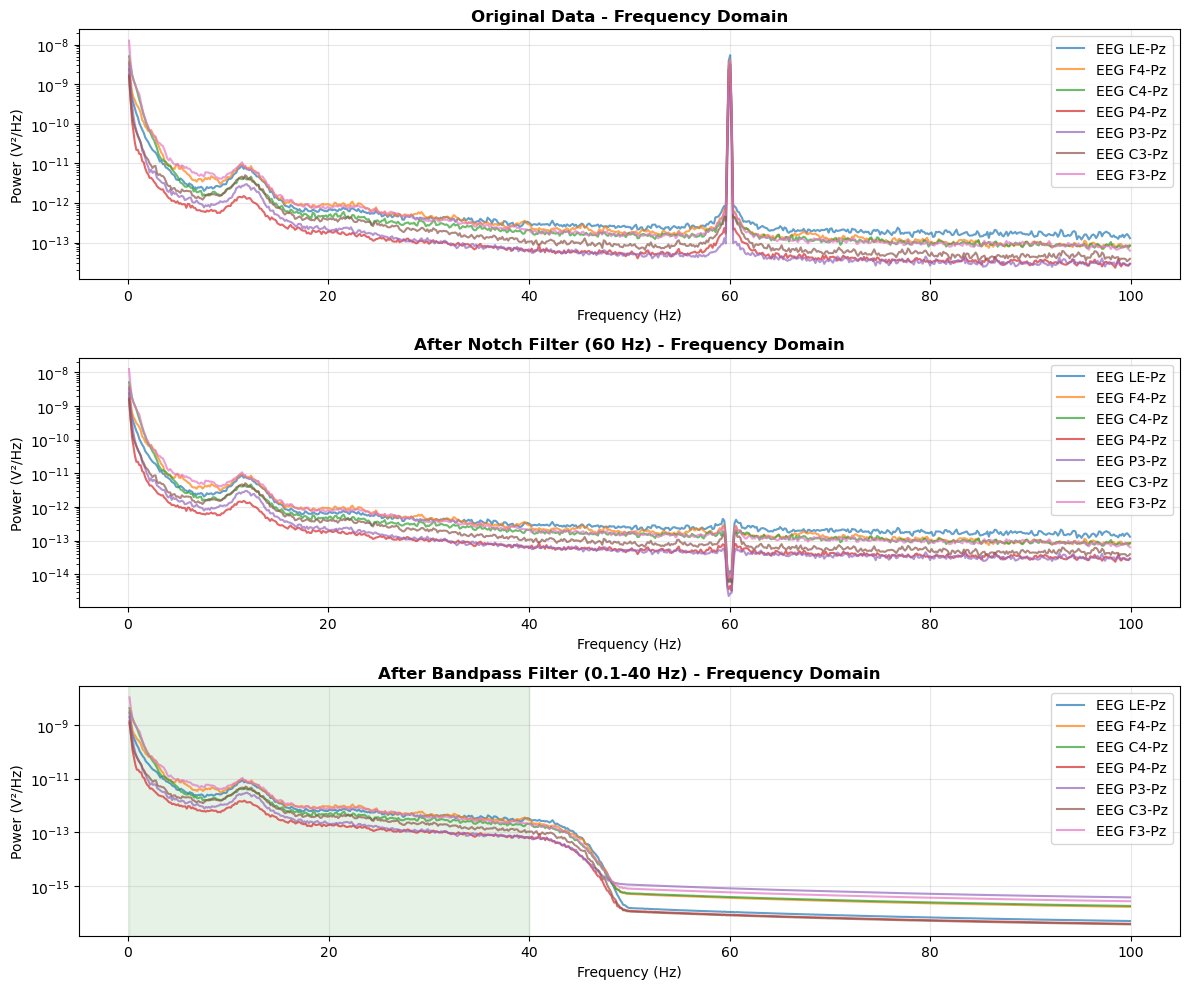

Done


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

LOW_CUT = 0.1
HIGH_CUT = 40

# Save a copy & initialize plotting
raw_original = raw.copy()
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
eeg_channels = [name for name in raw_original.ch_names if "EEG" in name]

# 1. ORIGINAL DATA
psd_original, freqs_original = mne.time_frequency.psd_array_welch(
    raw_original.get_data(), fmin=0.1, fmax=100, n_fft=2048, sfreq=info['sfreq']
)
ax = axes[0]
for i, ch in enumerate(eeg_channels):
    ax.semilogy(freqs_original, psd_original[i], label=ch, alpha=0.7)
ax.set_title('Original Data - Frequency Domain', fontsize=12, fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (V²/Hz)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AFTER NOTCH FILTER
filtered_data = raw_original.copy().notch_filter(60)
psd_notch, freqs_notch = mne.time_frequency.psd_array_welch(
    filtered_data.get_data(), fmin=0.1, fmax=100, n_fft=2048, sfreq=info['sfreq']
)
ax = axes[1]
for i, ch in enumerate(eeg_channels):
    ax.semilogy(freqs_notch, psd_notch[i], label=ch, alpha=0.7)
ax.set_title('After Notch Filter (60 Hz) - Frequency Domain', fontsize=12, fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (V²/Hz)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. AFTER BANDPASS FILTER
filtered_data.filter(l_freq=LOW_CUT, h_freq=HIGH_CUT)
psd_bandpass, freqs_bandpass = mne.time_frequency.psd_array_welch(
    filtered_data.get_data(), fmin=0.1, fmax=100, n_fft=2048, sfreq=info['sfreq']
)
ax = axes[2]
for i, ch in enumerate(eeg_channels):
    ax.semilogy(freqs_bandpass, psd_bandpass[i], label=ch, alpha=0.7)
ax.set_title(f'After Bandpass Filter ({LOW_CUT}-{HIGH_CUT} Hz) - Frequency Domain',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (V²/Hz)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axvspan(LOW_CUT, HIGH_CUT, alpha=0.1, color='green', label='Pass band')

plt.tight_layout()
plt.show()

print("Done")

In [ ]:
import mne
import matplotlib.pyplot as plt


class MNEData():
    def __init__(self, fif_file: str, preload: bool = True):
        self.raw = mne.io.read_raw_fif(fif_file, preload=preload)
        self.info = self.raw.info.to_json_dict()
        self.eeg_channels = [name for name in self.raw.ch_names if "EEG" in name]

    def plot(self, before: mne.io.Raw, after: mne.io.Raw, before_title: str = "Before", after_title: str = "After"):
        """Plot PSD comparison between two Raw objects side by side."""
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))

        for ax, data, title in zip(axes, [before, after], [before_title, after_title]):
            psd, freqs = mne.time_frequency.psd_array_welch(
                data.get_data(), fmin=0.1, fmax=100, n_fft=2048, sfreq=self.info['sfreq']
            )
            for i, ch in enumerate(self.eeg_channels):
                ax.semilogy(freqs, psd[i], label=ch, alpha=0.7)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Frequency (Hz)')
            ax.set_ylabel('Power (V²/Hz)')
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def filter_power_noise(self, freq: float = 60.0, plot: bool = False):
        """Apply a notch filter to remove power line noise (default 60 Hz)."""
        before = self.raw.copy()
        self.raw.notch_filter(freq)

        if plot:
            self.plot(
                before, self.raw,
                before_title="Before Notch Filter",
                after_title=f"After Notch Filter ({freq} Hz)"
            )

        return self

    def filter_bandpass(self, low_cut: float, high_cut: float, plot: bool = False):
        """Apply a bandpass filter between low_cut and high_cut Hz."""
        before = self.raw.copy()
        self.raw.filter(l_freq=low_cut, h_freq=high_cut)

        if plot:
            fig, axes = plt.subplots(2, 1, figsize=(12, 8))

            for ax, data, title in zip(axes, [before, self.raw], ["Before Bandpass Filter", f"After Bandpass Filter ({low_cut}–{high_cut} Hz)"]):
                psd, freqs = mne.time_frequency.psd_array_welch(
                    data.get_data(), fmin=0.1, fmax=100, n_fft=2048, sfreq=self.info['sfreq']
                )
                for i, ch in enumerate(self.eeg_channels):
                    ax.semilogy(freqs, psd[i], label=ch, alpha=0.7)
                ax.set_title(title, fontsize=12, fontweight='bold')
                ax.set_xlabel('Frequency (Hz)')
                ax.set_ylabel('Power (V²/Hz)')
                ax.legend()
                ax.grid(True, alpha=0.3)

            axes[1].axvspan(low_cut, high_cut, alpha=0.1, color='green', label='Pass band')
            plt.tight_layout()
            plt.show()

        return self

Extracting EDF parameters from eeg/data_0002_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 433799  =      0.000 ...  1445.997 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1981 samples (6.603 s)

Effective window size : 6.827 (s)
Effective window size : 6.827 (s)


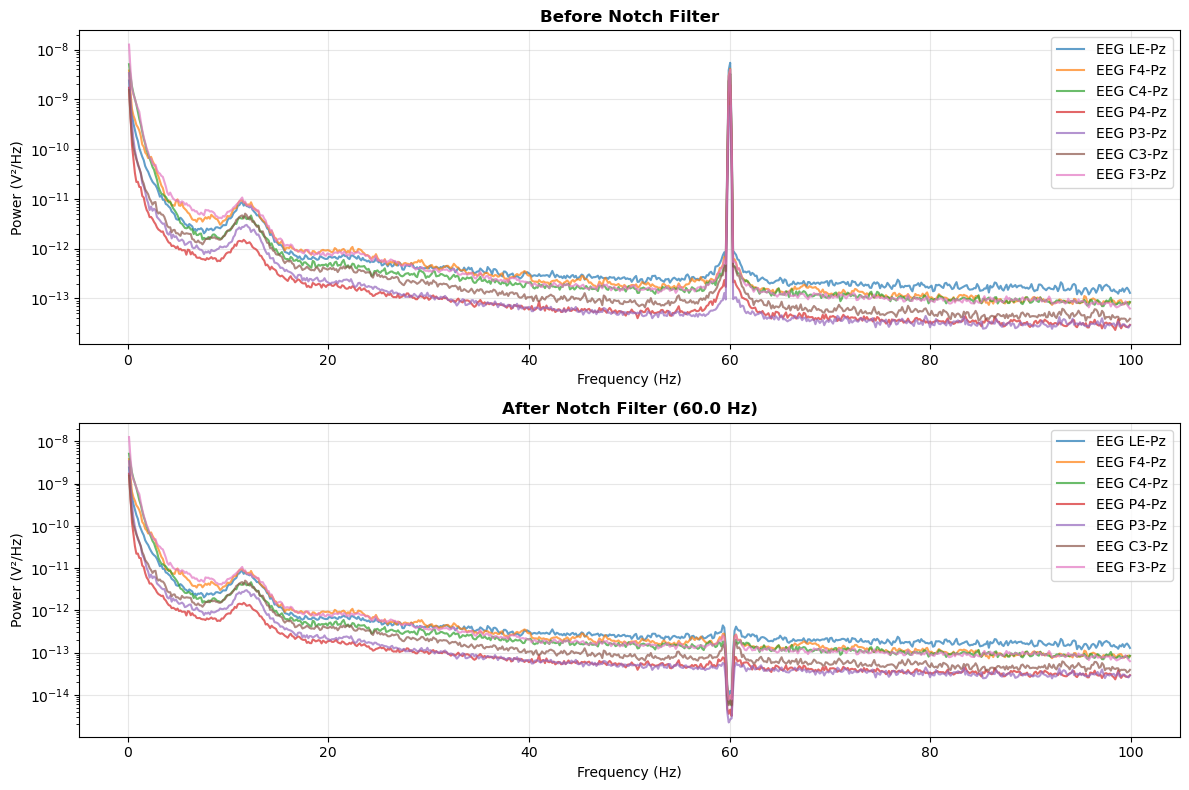

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 9901 samples (33.003 s)

Effective window size : 6.827 (s)
Effective window size : 6.827 (s)


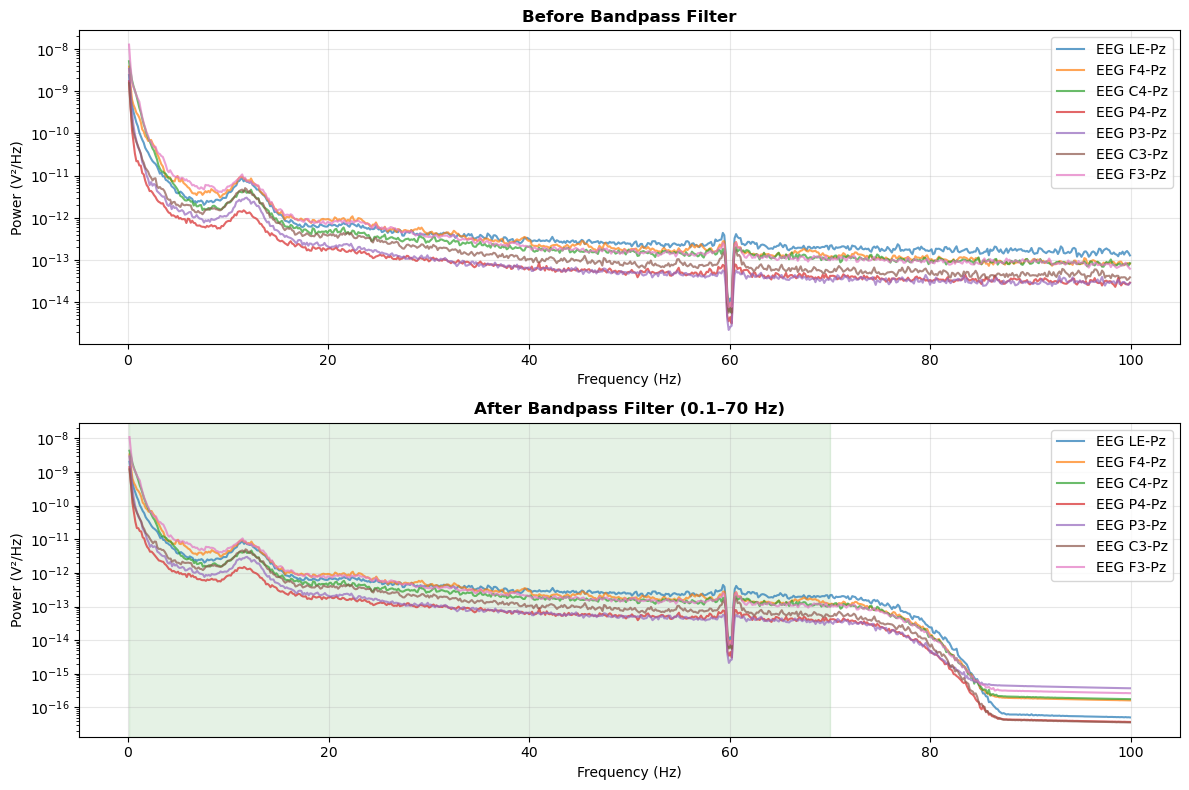

In [ ]:
# Example: (Note: I changed to read .edf files but the actual implementation does fif)

data = MNEData('eeg/data_0002_raw.edf')
data.filter_power_noise(plot=True)
data.filter_bandpass(low_cut=0.1, high_cut=70, plot=True)